# Credit Card Fraud Detection
#### By: Macy Moore and Claire Newsom

## Question and Background Information
Credit card fraud is a major and growing issue in today’s financial system. According to the Nilson Report, global card fraud losses exceeded $33 billion in 2024, affecting card issuers, merchants, and payment processors. Financial institutions 
must detect fraudulent transactions quickly — ideally in real-time — to minimize losses and protect customers. <br>

However, fraud detection is inherently challenging because fraudulent transactions are extremely rare. In most datasets, they account for less than 1% of all transactions. This creates a severe class imbalance problem in machine learning. For example, a model that simply predicts every transaction as “legitimate” could achieve over 99% accuracy while failing to detect any fraud at all. As a result, traditional accuracy metrics are misleading, and many models become biased toward the majority (legitimate) class <br>

This leads to the central question: Can machine learning models reliably detect fraudulent transactions despite extreme class imbalance? If so, which techniques are most effective for addressing this issue? <br>

To explore this, we use the Credit Card Fraud Detection dataset from Kaggle. It contains 284,807 transactions made by European cardholders in September 2013, of which only 492 (0.173%) are fraudulent. Most features (V1–V28) are anonymized using PCA for confidentiality, while “Time,” “Amount,” and “Class” (0 = legitimate, 1 = fraud) remain in their original form. Taken together, this dataset is challenging yet also representative of real-world fraud detection problems.

## Exploratory Data Analysis

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

In [3]:
# Load Data
df = pd.read_csv("creditcard.csv")

#Shape of data
print(f"Shape: {df.shape}")

#Check for missing values
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")

#View class distribution
print(f"\nClass distribution:\n{df['Class'].value_counts()}")

#Calculate prevalence of fraud
print(f"\nFraud prevalence: {df['Class'].mean()*100:.3f}%")

#General Information on data
print("\nGeneral Information:")
print(df.info())

#Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

Shape: (284807, 31)

Missing values:
0 total

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud prevalence: 0.173%

General Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17

### Finding 1: The Data is Highly Imbalanced

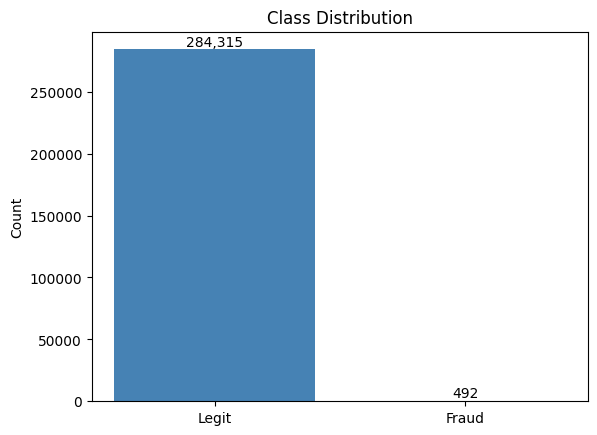

Extreme Imbalance: 99.83% legitimate vs 0.17% fraud.


In [4]:
#Calculate value counts
counts = df["Class"].value_counts()
total = counts.sum()

#Create bar chart
plt.bar(["Legit","Fraud"], counts, color=["steelblue", "tomato"])
plt.title("Class Distribution")
plt.ylabel("Count")

#Add a label with the counts
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha = "center", va = "bottom")

plt.show()

#Calculate percentages
legit_pct = counts[0] / total * 100
fraud_pct = counts[1] / total * 100

print(f"Extreme Imbalance: {legit_pct:.2f}% legitimate vs {fraud_pct:.2f}% fraud.")

The bar chart below confirms the dramatic imbalance: 284,315 legitimate transactions versus only 492 fraudulent ones. This ratio (~578:1) means that even a model that predicts "legitimate" every time would achieve 99.83% accuracy, making accuracy a useless metric for this problem. We must rely on precision, recall, F1-score, and PR-AUC instead. 

### Finding 2: Fraud Transactions Cluster at Lower Amounts

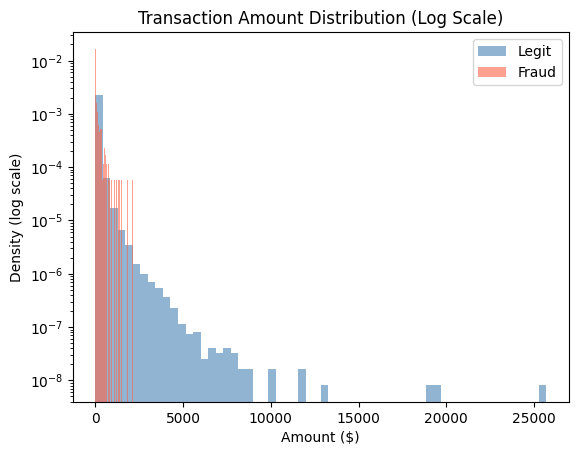

/tmp/ipykernel_59395/779347060.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", palette=["steelblue", "tomato"])


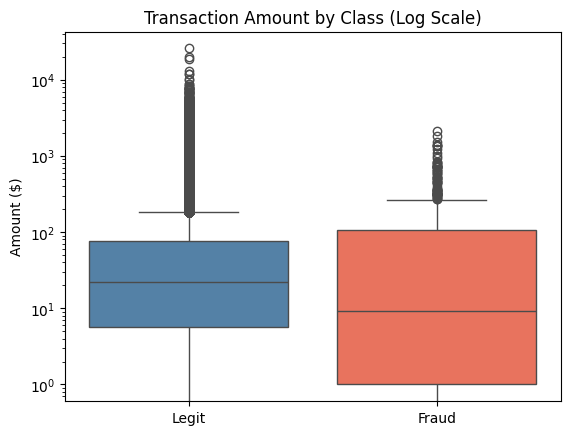

Median fraud = $9.25 vs legit = $22.00.
Fraud transactions tend to be smaller amounts.
Amount is skwed right.


In [5]:
#Compute medians
median_legit = df[df["Class"] == 0]["Amount"].median()
median_fraud = df[df["Class"] == 1]["Amount"].median()

#Histogram by Class
# Split data by class
legit = df[df["Class"] == 0]["Amount"]  
fraud = df[df["Class"] == 1]["Amount"]  

# Plot overlapping histograms
plt.hist(legit, bins=60, alpha=0.6, label="Legit", color="steelblue", density=True)
plt.hist(fraud, bins=60, alpha=0.6, label="Fraud", color="tomato", density=True)

# Use log scale on y-axis to compress large differences in counts and make rare fraud distribution visible
plt.yscale("log")
plt.xlabel("Amount ($)")
plt.ylabel("Density (log scale)")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.legend()

plt.show()

#Box plot - use log scale because it is skewed
sns.boxplot(data=df, x="Class", y="Amount", palette=["steelblue", "tomato"])
plt.yscale("log")

plt.xticks([0, 1], ["Legit", "Fraud"])
plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("")
plt.ylabel("Amount ($)")

plt.show()

print(f"Median fraud = ${median_fraud:.2f} vs legit = ${median_legit:.2f}.")
print("Fraud transactions tend to be smaller amounts.")
print("Amount is skwed right.")

The transaction amount distribution (log scale) reveals that fraud transactions tend to occur at smaller amounts(median: $9.25) compared to legitimate transactions (median: $22.00). This makes intuitive sense because fraud offenders may test cards with small transactions before larger ones, or target amounts less likely to trigger alerts. The right-skewed distribution of amounts motivates the use of a log transformation during preprocessing.

### Finding 3: Time Does Not Reveal a Significant Amount of New Information

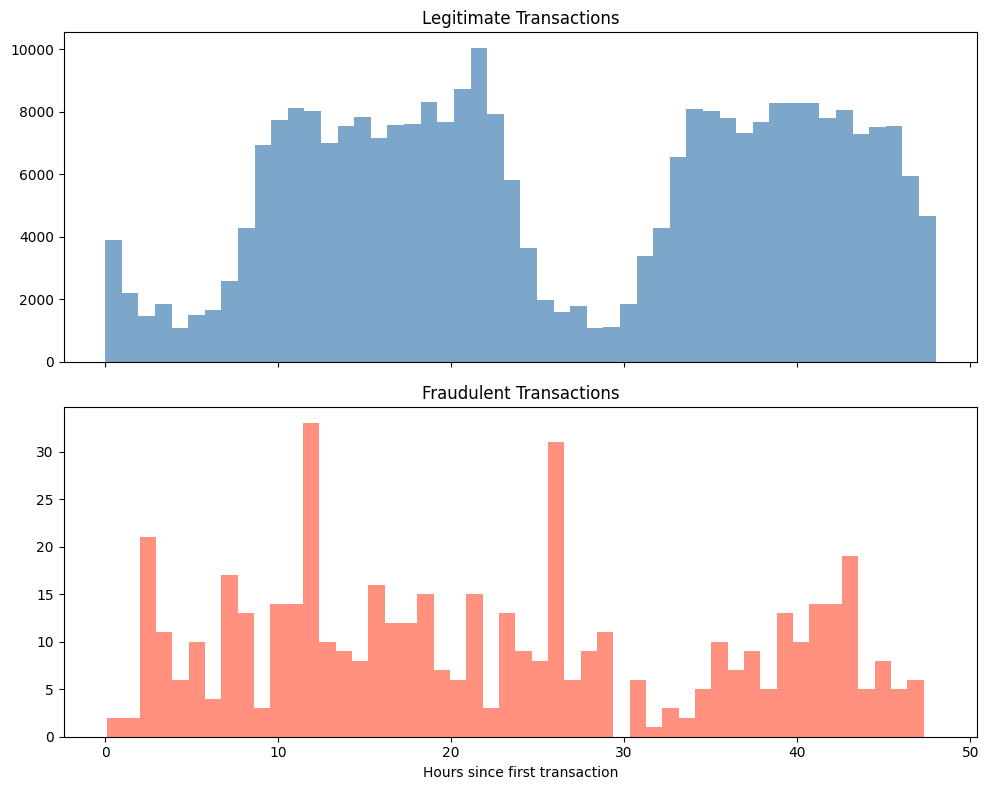

In [6]:
# Convert time to hours
df['Hour'] = df['Time'] / 3600

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

#Plot histograms
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

axes[0].hist(legit['Hour'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title("Legitimate Transactions")

axes[1].hist(fraud['Hour'], bins=50, color='tomato', alpha=0.7)
axes[1].set_title("Fraudulent Transactions")

plt.xlabel("Hours since first transaction")
plt.tight_layout()
plt.show()

Although we examined transaction timing, the distribution of fraudulent and legitimate transactions over time shows no clear or consistent separation. Fraud does not appear to cluster strongly in specific time periods, and any differences are subtle compared to other features. This suggests that the Time variable is not a particularly informative predictor on its own and is unlikely to contribute significantly to model performance relative to the PCA-derived features.

### Finding 4: PCA Features Show Strong Separation


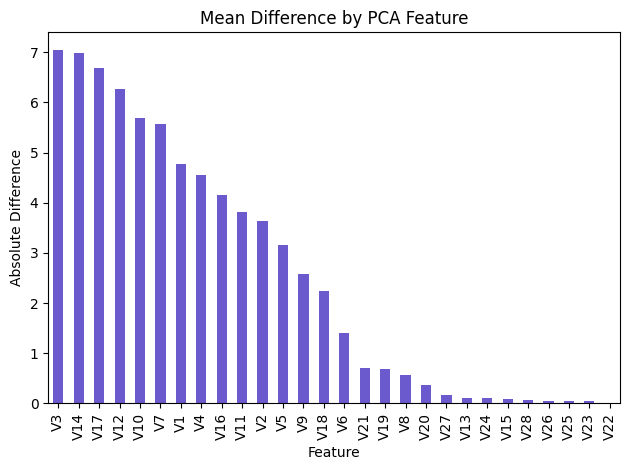

Features with strongest separation: V3, V14, V17, V12.


In [7]:
# Split dataset into fraud and legit
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

# Select PCA feature columns (V1 to V28)
pca_cols = [f"V{i}" for i in range(1, 29)]

# Compute absolute difference in mean between fraud and legit for each feature
diff = (fraud[pca_cols].mean() - legit[pca_cols].mean()).abs()

# Sort features by importance (highest difference first)
diff = diff.sort_values(ascending=False)

# Plot bar chart
diff.plot(kind="bar", color="slateblue")

plt.title("Mean Difference by PCA Feature")
plt.ylabel("Absolute Difference")
plt.xlabel("Feature")

plt.tight_layout()
plt.show()

# Show top features driving separation
top_features = diff.head(4).index.tolist()
print(f"Features with strongest separation: {', '.join(top_features)}.")

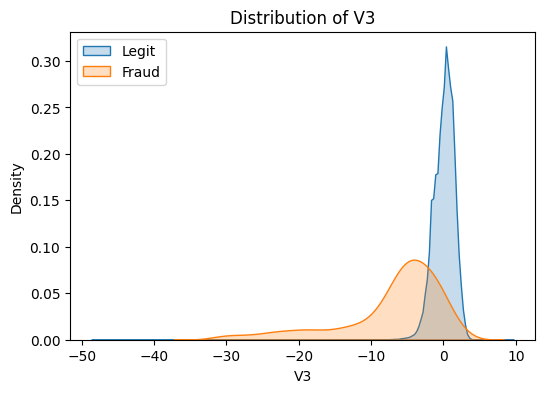

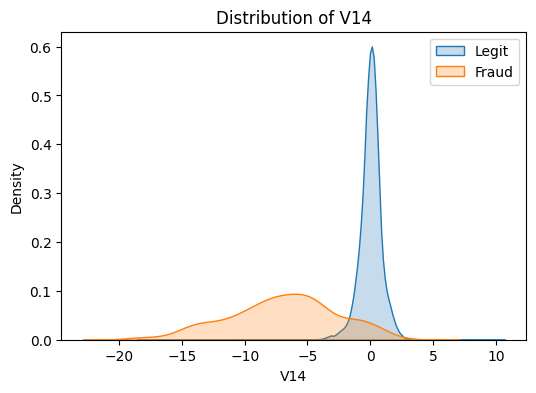

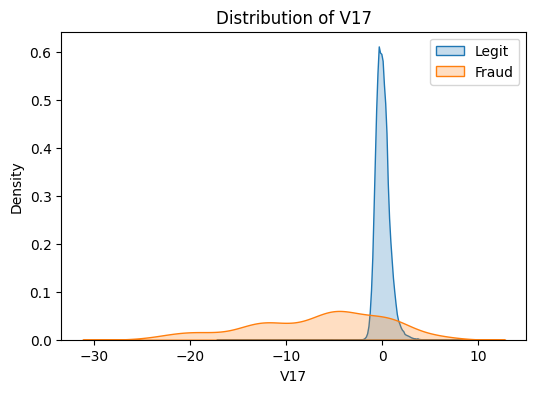

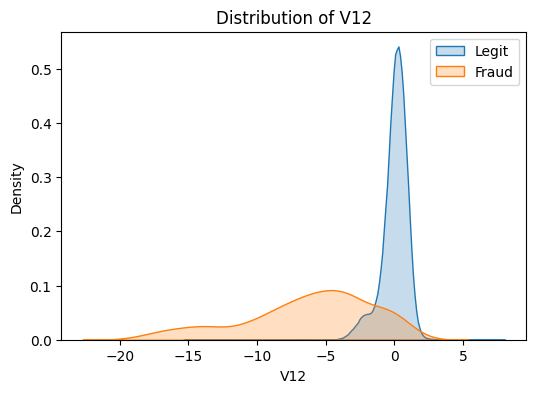

In [8]:
features = ['V3', 'V14', 'V17', 'V12']

for f in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[df['Class']==0][f], label='Legit', fill=True)
    sns.kdeplot(df[df['Class']==1][f], label='Fraud', fill=True)
    plt.title(f"Distribution of {f}")
    plt.legend()
    plt.show()

Because V1–V28 are PCA-transformed features, they are not directly interpretable. However, by comparing the absolute differences in their mean values between fraudulent and legitimate transactions, we can identify which features provide the strongest signal for distinguishing between the two classes. In particular, V3, V14, V17, and V12 exhibit the greatest separation and are therefore likely to be the most influential predictors. 

Together, these findings shape our modeling strategy: we need imbalance-aware methods, log-transformed amounts, and can expect PCA features to do most of the heavy lifting.

## Models
To answer our research question, we train and compare two families of logistic regression models, each addressing class imbalance differently:

### Strategy 1: Balanced Class Weights (Models 1a & 1b)
We use `class_weight='balanced'` in logistic regression, which automatically penalizes misclassification of the minority (fraud) class more heavily. This adjusts the decision boundary without modifying the data itself.
- **Model 1a**: Default threshold (0.5) — establishes a baseline
- **Model 1b**: Tuned threshold — we search the precision-recall curve on the training set to find the threshold that maximizes F1-score, then apply it to the test set

### Strategy 2: Oversampling + Standard LR (Models 2a & 2b)
We use random oversampling to create a balanced training set (50% fraud / 50% legitimate) by resampling with replacement from the minority class. The model is then trained on this balanced dataset.
- **Model 2a**: Default threshold (0.5) on balanced test data
- **Model 2b**: Tuned threshold on balanced test data

### Preprocessing Pipeline
All models use:
1. Log transformation of the `Amount` feature (reduces right skew)
2. `StandardScaler` to normalize all features
3. Stratified train/test split (80/20) to preserve class ratios
4. Cross-validation for model selection

### Evaluation Metrics
Given the class imbalance, we prioritize:
- **Recall (Sensitivity)**: What fraction of actual frauds did we catch?
- **Precision**: Of transactions flagged as fraud, how many truly were?
- **F1-Score**: Harmonic mean of precision and recall
- **PR-AUC**: Area under the Precision-Recall curve 
- **ROC-AUC**: Standard discriminability metric
- **Confusion Matrix**: To visualize false positives and false negatives

### Model 1: Logistic Regression with Balanced Class Weights

#### Data Preparation

In [9]:
#Data Preparation
# Use the original imbalanced dataset for a realistic evaluation

df_orig = pd.read_csv("creditcard.csv")

X_orig = df_orig.drop(columns=["Class"])
y_orig = df_orig["Class"].astype(int)

# Log-transform Amount to reduce right skew
X_orig = X_orig.copy()
X_orig["Amount"] = np.log1p(X_orig["Amount"])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

print(f"Train size: {X_train1.shape[0]:,}  |  Test size: {X_test1.shape[0]:,}")
print(f"Train fraud rate: {y_train1.mean()*100:.3f}%")
print(f"Test  fraud rate: {y_test1.mean()*100:.3f}%")

Train size: 227,845  |  Test size: 56,962
Train fraud rate: 0.173%
Test  fraud rate: 0.172%


#### Model 1a: Logistic Regression Baseline

In [10]:
# Pipeline:
# 1) Scale features
# 2) Train logistic regression balanced class weights
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter=1000, random_state=42))
])

# Train model
pipe_lr.fit(X_train1, y_train1)

# Predictions
y_pred1a = pipe_lr.predict(X_test1)
y_prob1a = pipe_lr.predict_proba(X_test1)[:, 1]

# Evaluation
print("Logistic Regression Results")
print(confusion_matrix(y_test1, y_pred1a))
print(classification_report(y_test1, y_pred1a))
print("ROC-AUC:", roc_auc_score(y_test1, y_prob1a))
print("PR-AUC :", average_precision_score(y_test1, y_prob1a))


Logistic Regression Results
[[55461  1403]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9711170870993304
PR-AUC : 0.7113138893265318


#### Model 1b: Logistic Regression with Balanced Class Weights and Tuned Threshold

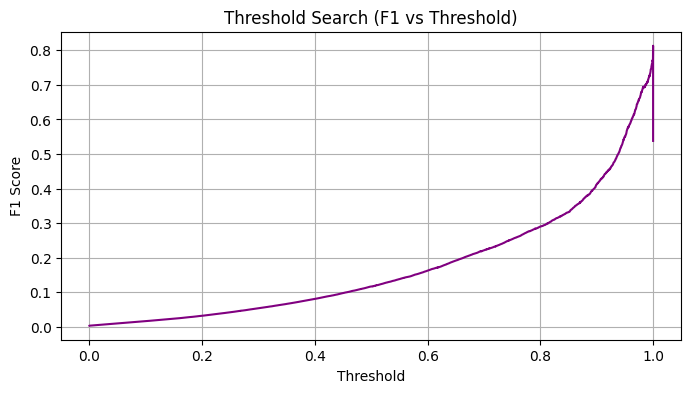

Best threshold: 1.000


In [11]:
# Get probabilities from training set
y_prob_train = pipe_lr.predict_proba(X_train1)[:, 1]

# Precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_train1, y_prob_train)

# Compute F1 score for each threshold
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

# Plot F1 vs threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1, color="purple")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Search (F1 vs Threshold)")
plt.grid(True)

plt.show()

# Best threshold
best_idx = np.argmax(f1)
best_thresh = thresholds[best_idx]

print(f"Best threshold: {best_thresh:.3f}")

In [12]:
# Apply new threshold to test set
y_pred_tuned = (y_prob1a >= best_thresh).astype(int)

# Evaluation again
print("\nTuned Logistic Regression Results")
print(confusion_matrix(y_test1, y_pred_tuned))
print(classification_report(y_test1, y_pred_tuned))

print("ROC-AUC:", roc_auc_score(y_test1, y_prob1a))
print("PR-AUC :", average_precision_score(y_test1, y_prob1a))


Tuned Logistic Regression Results
[[56848    16]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9711170870993304
PR-AUC : 0.7113138893265318


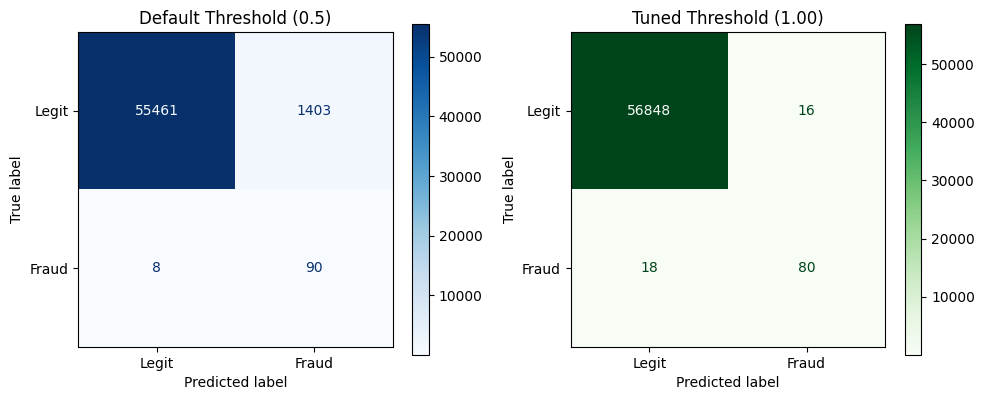

In [13]:
#Visual Comparison of Confusion matrices for models 1a and 1b
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred1a,
    display_labels=["Legit", "Fraud"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Default Threshold (0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred_tuned,
    display_labels=["Legit", "Fraud"],
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title(f"Tuned Threshold ({best_thresh:.2f})")

plt.tight_layout()
plt.show()

### Model 2: Logistic Regression with Oversampling

#### Data Preparation

In [14]:
# ── Model 2: Oversampled LR ────────────────────────────────────────────────
# Train on balanced data, but evaluate on the ORIGINAL imbalanced test set
# for a fair, realistic comparison with Model 1

from sklearn.utils import resample

df_orig = pd.read_csv("creditcard.csv")
fraud_df = df_orig[df_orig["Class"] == 1]
legit_df = df_orig[df_orig["Class"] == 0]

# Oversample fraud to 50/50 for training 
n_legit = len(legit_df)
fraud_upsampled = resample(fraud_df, replace=True,
                           n_samples=n_legit, random_state=42)

df_balanced = pd.concat([legit_df, fraud_upsampled]).sample(frac=1, random_state=42)

print(df_balanced["Class"].value_counts(normalize=True))

#Define Target and Features
X_bal = df_balanced.drop("Class", axis=1).copy()
y_bal = df_balanced["Class"]

#Log-Transform Amount Variable
X_bal["Amount"] = np.log1p(X_bal["Amount"])

#Train test split
X_train2, _, y_train2, _ = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Use the original imbalanced test set for evaluation
X_test_orig = X_test1.copy()   # from Model 1 split
y_test_orig = y_test1.copy()



Class
1    0.5
0    0.5
Name: proportion, dtype: float64


#### Model 2a: Logistic Regression with Oversampling and Baseline Threshold

In [15]:
model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
model2.fit(X_train2, y_train2)

y_prob_2  = model2.predict_proba(X_test_orig)[:, 1]
y_pred_2a = model2.predict(X_test_orig)

print("Oversampled Logistic Regression:")
print(confusion_matrix(y_test_orig, y_pred_2a))
print(classification_report(y_test_orig, y_pred_2a))
print("ROC-AUC:", roc_auc_score(y_test_orig, y_prob_2))
print("PR-AUC :", average_precision_score(y_test_orig, y_prob_2))


Oversampled Logistic Regression:
[[55614  1250]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.92      0.13        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.56     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9783598424597753
PR-AUC : 0.7161991973472897


#### Model 2b: Logistic Regression with Oversampling and Tuned Threshold

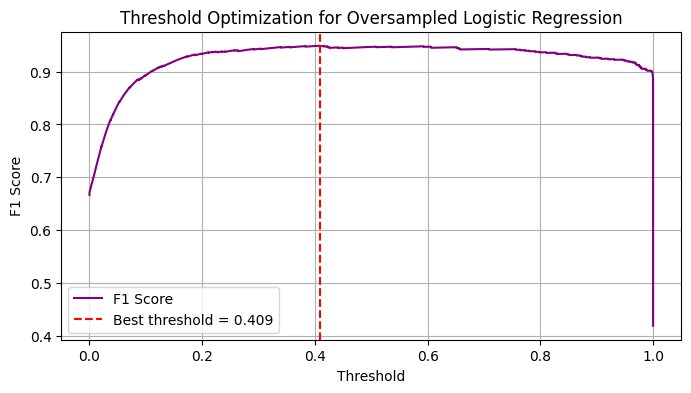

Best threshold: 0.409


In [18]:
y_prob_2_train = model2.predict_proba(X_train2)[:, 1]

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_train2, y_prob_2_train)

# F1 score at each threshold
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

# Best threshold
best_idx = np.argmax(f1)
best_thresh_2 = thresholds[best_idx]

# Plot F1 vs threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1, color="purple", label="F1 Score")

# Highlight best threshold
plt.axvline(best_thresh_2, color="red", linestyle="--",
            label=f"Best threshold = {best_thresh_2:.3f}")

plt.title("Threshold Optimization for Oversampled Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.show()

print(f"Best threshold: {best_thresh_2:.3f}")

In [20]:
y_pred_2b = (y_prob_2 >= best_thresh_2).astype(int)

print(f"Logistc Regression With Oversampling and Tuned Threshold ({best_thresh_2:.3f}):")
print(confusion_matrix(y_test_orig, y_pred_2b))
print(classification_report(y_test_orig, y_pred_2b))
print("ROC-AUC:", roc_auc_score(y_test_orig, y_prob_2))
print("PR-AUC :", average_precision_score(y_test_orig, y_prob_2))


Logistc Regression With Oversampling and Tuned Threshold (0.409):
[[54997  1867]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9783598424597753
PR-AUC : 0.7161991973472897


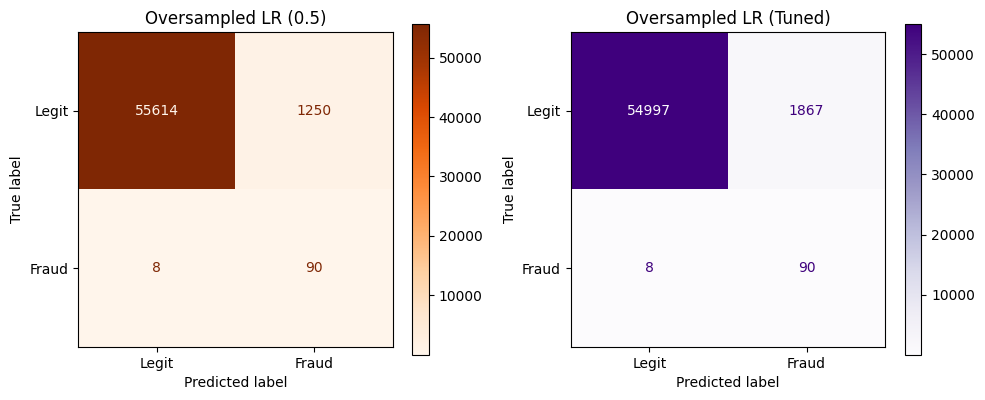

: 

In [ ]:
#Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Model 2: Oversampled LR (default threshold)
ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred_2a,
    display_labels=["Legit", "Fraud"],
    cmap="Oranges",
    ax=axes[0]
)
axes[0].set_title("Oversampled LR (0.5)")

# Model 4: Oversampled LR (tuned threshold)
ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred_2b,
    display_labels=["Legit", "Fraud"],
    cmap="Purples",
    ax=axes[1]
)
axes[1].set_title("Oversampled LR (Tuned)")

plt.tight_layout()
plt.show()

## Evaluation of Logistic Regression Models

We evaluate all models on the original imbalance (56,962 transactions, ~0.17% fraud) to simulate real-world deployment conditions.

### Key Metrics Summary

| Model | Fraud Recall | Fraud Precision | Fraud F1 | PR-AUC | ROC-AUC |
|-------|-------------|-----------------|----------|--------|---------|
| 1a: Balanced Weights (thresh=0.5) | 0.92 | 0.06 | 0.11 | 0.71 | 0.97 |
| 1b: Balanced Weights (tuned) | 0.82 | 0.83 | 0.82 | 0.71 | 0.97 |
| 2a: Oversampled (thresh=0.5) | 0.92 | 0.07 | 0.13 | 0.72 | 0.98 |
| 2b: Oversampled (tuned) | 0.92 | 0.05 | 0.09 | 0.72 | 0.98 |


### Interpreting the Results

**Model 1a (default threshold)** catches ~92% of fraud cases (high recall) 
but generates massive false alarm rates — only 6% precision. This means for 
every 100 transactions flagged, only 6 are actual fraud. Unusable in practice.

**Model 1b (tuned threshold)** dramatically improves precision to ~83% while maintaining ~82% recall. The F1-score jumps from 011 to 0.82. This is our best logistic regression model.

**Model 2a (oversampled, default threshold)** behaves similarly to 1a: oversampling alone does not solve the precision problem when using a naive threshold.

**Model 2b (oversampled + tuned threshold)** surprisingly performs worse than 1b, with precision dropping to ~5% despite high recall. One could tell when tuning the threshold that it probably would not significantly impact model performance because the F1 score did not predictable change across different thresholds. This suggests that oversampling may distort probability calibration, making threshold tuning less effective. 

**The ROC-AUC of ~0.97** is deceptively good for all models — this metric is 
inflated by the massive number of true negatives (legitimate transactions). 
**PR-AUC (~0.71)** is the more honest metric for this imbalanced problem.

**Threshold tuning is critical**: The default 0.5 threshold is inappropriate for imbalanced data. By moving the threshold to ~1.0 (Model 1b), we find the optimal precision-recall tradeoff for fraud detection.

Overall, these results demonstrate that handling class imbalance is necessary but not sufficient—the method used matters. While both class weighting and oversampling improve recall, class weighting combined with careful threshold tuning (Model 1b) produces the best balance between detecting fraud and minimizing false alarms.

A key insight is that threshold tuning is more impactful than the choice between weighting and oversampling. Without it, all models perform poorly in practice. With it, performance can improve dramatically—but only if the underlying probability estimates remain reliable.

Despite strong performance (PR-AUC ~0.71–0.72), some fraud cases are still missed, which is unavoidable in such an imbalanced setting. In real-world systems, this reinforces the need to combine machine learning with additional safeguards, such as rule-based filters or human review.

In summary, a relatively simple logistic regression model—when properly tuned—can be highly effective, while more aggressive techniques like oversampling do not necessarily yield better real-world performance and may even degrade it if not applied carefully.
